# Description - To run within SCC
# Creates results using Dense Model
# Currently, the file is created targeting the model saved in the path below
# restricted/projectnb/movelab/bcha/IMUforKnee/trainedModel/Dense_1st_torch/IWALQQ_AE_4th/

In [1]:
import torch
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import os
from os.path import join
from pickle import load
import pandas as pd
from natsort import natsorted
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

# Add the path to access helper modules (Windows path)
import sys
sys.path.append(r'R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\IMUforKnee\estimation\sensorwise')

# Import custom libraries
from dir_CBD import *
from plot_CBD import *
from scaler_CBD import *


In [2]:
motherDir = 'DenseModel'
exp_name = 'date_Optuna_AutoSearch'
modelVersion = 'Optuna_AutoSearch'
nameDataset = 'IWALQQ_1st_correction'
dataType = 'angle'

# ---- Correct roots ----
# Root where the training script wrote everything
OUTPUT_ROOT = r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\Optuna_AutoSearch"

# Models actually live (per training script) in:  <OUTPUT_ROOT>\models\final_models
MODEL_DIR   = os.path.join(OUTPUT_ROOT, "models", "final_models")

# Dataset directory containing the fold .npz and scaler .pkl files:
DATA_DIR = r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Data\allnew_20220325_raw_byDeepak_csv\INC_ByStep\INC_ByZero\Included_checked\SAVE_dataSet"
DATA_DIR = os.path.join(DATA_DIR, nameDataset)

SEQ_LEN = 101
NUM_FEATURES = 42

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("MODEL_DIR:", MODEL_DIR)
print("DATA_DIR :", DATA_DIR)

# Quick sanity: list a few files so you can confirm
print("Model dir sample:", os.listdir(MODEL_DIR)[:8])
print("Data dir sample :", os.listdir(DATA_DIR)[:8])


Device: cuda
MODEL_DIR: R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\Optuna_AutoSearch\models\final_models
DATA_DIR : R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Data\allnew_20220325_raw_byDeepak_csv\INC_ByStep\INC_ByZero\Included_checked\SAVE_dataSet\IWALQQ_1st_correction
Model dir sample: ['angle_fold_0_optuna_best.pt', 'angle_fold_0_optuna_best_config.json', 'angle_fold_0_optuna_best_state_dict.pt', 'angle_fold_1_optuna_best.pt', 'angle_fold_1_optuna_best_config.json', 'angle_fold_1_optuna_best_state_dict.pt', 'angle_fold_2_optuna_best.pt', 'angle_fold_2_optuna_best_config.json']
Data dir sample : ['0_fold_final_test.npz', '0_fold_final_train.npz', '0_fold_scaler4X.pkl', '0_fold_scaler4Y_angle.pkl', '0_fold_scaler4Y_moBWHT.pkl', '1_fold_final_test.npz', '1_fold_final_train.npz', '1_fold_scaler4X.pkl']


In [3]:
# ADD THIS NEW CELL BEFORE YOUR INFERENCE LOOP
import torch.nn as nn
import torch.nn.functional as F

class ConfigurableModel(nn.Module):
    """Configurable neural network architecture"""
    def __init__(self, config):
        super().__init__()
        
        self.n_layers = config['n_layers']
        self.hidden_dims = config['hidden_dims']
        self.dropout_rates = config['dropout_rates']
        self.use_batch_norm = config['use_batch_norm']
        self.activation = config['activation']
        
        # Input/output dimensions
        input_dim = 4242
        output_dim = 303
        
        # Build layers
        self.flatten = nn.Flatten()
        self.layers = nn.ModuleList()
        self.batch_norms = nn.ModuleList()
        self.dropouts = nn.ModuleList()
        
        # Hidden layers
        prev_dim = input_dim
        for i in range(self.n_layers):
            self.layers.append(nn.Linear(prev_dim, self.hidden_dims[i]))
            
            if self.use_batch_norm:
                self.batch_norms.append(nn.BatchNorm1d(self.hidden_dims[i]))
            else:
                self.batch_norms.append(nn.Identity())
            
            self.dropouts.append(nn.Dropout(self.dropout_rates[i]))
            prev_dim = self.hidden_dims[i]
        
        # Output layer
        self.output_layer = nn.Linear(prev_dim, output_dim)
    
    def forward(self, x):
        x = self.flatten(x)
        
        for i in range(self.n_layers):
            x = self.layers[i](x)
            
            if self.use_batch_norm:
                if self.training and x.size(0) == 1:
                    pass
                else:
                    x = self.batch_norms[i](x)
            
            if self.activation == 'relu':
                x = F.relu(x)
            elif self.activation == 'gelu':
                x = F.gelu(x)
            elif self.activation == 'swish':
                x = F.silu(x)
            elif self.activation == 'tanh':
                x = torch.tanh(x)
            elif self.activation == 'leaky_relu':
                x = F.leaky_relu(x, 0.1)
            
            x = self.dropouts[i](x)
        
        return self.output_layer(x)

In [4]:
# Angle prediction model - CORRECTED VERSION
for numFold in range(0, 5):
    # Load model - FIXED: Use correct file naming pattern and loading method
    dir_savedTrainedModel = join(MODEL_DIR, f"{dataType}_fold_{numFold}_optuna_best.pt")
    print(f"Loading model: {dir_savedTrainedModel}")  # Add this to verify the path
    
    # Try different loading methods depending on how the model was saved
    try:
        # First try torch.jit.load for TorchScript models
        my_model = torch.jit.load(dir_savedTrainedModel, map_location='cpu')
        print("Loaded as TorchScript model")
    except RuntimeError as e:
        if "constants.pkl" in str(e):
            # If it fails with constants.pkl error, try regular torch.load
            print("TorchScript failed, trying regular torch.load...")
            my_model = torch.load(dir_savedTrainedModel, map_location='cpu', weights_only=False)
            print("Loaded as regular PyTorch model")
        else:
            raise e
    
    my_model.eval()
    
    # Load data
    load_test = np.load(join(DATA_DIR, f"{numFold}_fold_final_test.npz"))
    load_scaler4Y = load(
        open(join(DATA_DIR, f"{numFold}_fold_scaler4Y_{dataType}.pkl"), "rb")
    )
    
    print(f"Processing fold {numFold} with {load_test['final_X_test'].shape[0]} samples")
    
    # Iterate through individual data for each fold
    for dataIndex in range(load_test["final_X_test"].shape[0]):
        # Prepare input and ground truth data
        X_test = np.squeeze(load_test["final_X_test"][dataIndex])
        X_test = X_test[None, :]  # Add batch dimension
        Y_true = load_test[f"final_Y_{dataType}_test"][dataIndex]
        
        # Inference
        Y_pred = my_model(
            torch.from_numpy(X_test).type(torch.FloatTensor))
        Y_pred = Y_pred.cpu().detach().numpy()
        Y_pred = np.reshape(Y_pred, [3, -1])
        Y_pred = np.transpose(Y_pred)
        
        # Reshape Y_true the same way as Y_pred (convert 303-length flat array to 101x3 matrix)
        Y_true = np.reshape(Y_true, [3, -1])
        Y_true = np.transpose(Y_true)
        
        # Rescale data back to original size
        Y_true_pick_afterscaler = (Y_true - load_scaler4Y.min_) / load_scaler4Y.scale_
        Y_pred_pick_afterscaler = (Y_pred - load_scaler4Y.min_) / load_scaler4Y.scale_
        
        df_true = pd.DataFrame(Y_true_pick_afterscaler, columns=['X_True','Y_True','Z_True'])
        df_pred = pd.DataFrame(Y_pred_pick_afterscaler, columns=['X_Pred','Y_Pred','Z_Pred'])
        df_save = pd.concat([df_true, df_pred], axis=1)
        dfSaveDir = join(motherDir,modelVersion,nameDataset,dataType,f"{numFold}_fold")
        ensure_dir(dfSaveDir)
        df_save.to_excel(join(dfSaveDir,f"{dataIndex}.xlsx"))
    #     break  # For test data loop break
    # break  # For fold loop break

Loading model: R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\Optuna_AutoSearch\models\final_models\angle_fold_0_optuna_best.pt
TorchScript failed, trying regular torch.load...
Loaded as regular PyTorch model
Processing fold 0 with 154 samples
Loading model: R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\Optuna_AutoSearch\models\final_models\angle_fold_1_optuna_best.pt
TorchScript failed, trying regular torch.load...
Loaded as regular PyTorch model
Processing fold 1 with 209 samples
Loading model: R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\Optuna_AutoSearch\models\final_models\angle_fold_2_optuna_best.pt
TorchScript failed, trying regular torch.load...
Loaded as regular PyTorch model
Processing fold 2 with 154 samples
Loading model: R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\Optuna_AutoSearch\models\final_models\angle_fo

In [5]:
# import 필요한 라이브러리
import os
from os.path import join
from natsort import natsorted
from pathlib import Path
import shutil
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from mpl_toolkits.axes_grid1 import host_subplot
import mpl_toolkits.axisartist as AA
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import plot_CBD

In [6]:
# Main folder name to contain the results
targetDir = join(motherDir,modelVersion,nameDataset,dataType)
for axe in ["X","Y","Z"]:
    print("Axe : ", axe)
    globals()[f"true_{axe}"] = np.array([])
    globals()[f"pred_{axe}"] = np.array([])
    for fold in ["0_fold","1_fold","2_fold","3_fold","4_fold",]:
        print(f"now fold : ", fold)
        list_results = natsorted([_ for _ in os.listdir(join(targetDir,fold)) if _.endswith(".xlsx")])
        for result in list_results:
            singleResult = pd.read_excel(join(targetDir,fold,result))
            true = np.expand_dims(singleResult[f"{axe}_True"].to_numpy(), axis=0)
            pred = np.expand_dims(singleResult[f"{axe}_Pred"].to_numpy(), axis=0)
            
            # Better debug: Check the actual values
            if axe == "Y" and result == "0.xlsx":
                print(f"File: {fold}/{result}")
                print(f"Y_Pred from Excel: {singleResult['Y_Pred'].iloc[:5].values}")
                print(f"pred array: {pred[0, :5]}")
                print(f"pred has NaN: {np.isnan(pred).any()}")
                print(f"Excel Y_Pred has NaN: {singleResult['Y_Pred'].isna().any()}")
                break
            
            if len(globals()[f"true_{axe}"]) ==0:
                globals()[f"true_{axe}"] = true
                globals()[f"pred_{axe}"] = pred
            else:
                globals()[f"true_{axe}"] = np.concatenate((globals()[f"true_{axe}"], true),0)
                globals()[f"pred_{axe}"] = np.concatenate((globals()[f"pred_{axe}"], pred),0)

Axe :  X
now fold :  0_fold
now fold :  1_fold
now fold :  2_fold
now fold :  3_fold
now fold :  4_fold
Axe :  Y
now fold :  0_fold
File: 0_fold/0.xlsx
Y_Pred from Excel: [-1.78188884 -1.63210345 -1.57461144 -1.42803017 -1.32810007]
pred array: [-1.78188884 -1.63210345 -1.57461144 -1.42803017 -1.32810007]
pred has NaN: False
Excel Y_Pred has NaN: False
now fold :  1_fold
File: 1_fold/0.xlsx
Y_Pred from Excel: [0.04245451 0.01209236 0.02990143 0.03826794 0.07265182]
pred array: [0.04245451 0.01209236 0.02990143 0.03826794 0.07265182]
pred has NaN: False
Excel Y_Pred has NaN: False
now fold :  2_fold
File: 2_fold/0.xlsx
Y_Pred from Excel: [-2.02564258 -1.8213357  -1.7694186  -1.4035867  -1.87419051]
pred array: [-2.02564258 -1.8213357  -1.7694186  -1.4035867  -1.87419051]
pred has NaN: False
Excel Y_Pred has NaN: False
now fold :  3_fold
File: 3_fold/0.xlsx
Y_Pred from Excel: [-2.09130252 -1.94243575 -1.67897993 -1.59658605 -1.43135405]
pred array: [-2.09130252 -1.94243575 -1.67897993 -1

In [7]:
def makeDataframe(file_Num):
    return pd.DataFrame(data=file_Num.transpose(),index = [idx for idx in range(len(file_Num[0]))],columns=[idx for idx in range(len(file_Num))])

In [8]:
# Rebuild arrays from the fixed Excel files
targetDir = join(motherDir,modelVersion,nameDataset,dataType)

true_X = np.array([])
pred_X = np.array([])
true_Y = np.array([])
pred_Y = np.array([])
true_Z = np.array([])
pred_Z = np.array([])

for fold in ["0_fold","1_fold","2_fold","3_fold","4_fold"]:
    list_results = natsorted([_ for _ in os.listdir(join(targetDir,fold)) if _.endswith(".xlsx")])
    for result in list_results:
        df = pd.read_excel(join(targetDir,fold,result))
        
        for axe in ["X","Y","Z"]:
            true_data = np.expand_dims(df[f"{axe}_True"].to_numpy(), axis=0)
            pred_data = np.expand_dims(df[f"{axe}_Pred"].to_numpy(), axis=0)
            
            if len(globals()[f"true_{axe}"]) == 0:
                globals()[f"true_{axe}"] = true_data
                globals()[f"pred_{axe}"] = pred_data
            else:
                globals()[f"true_{axe}"] = np.concatenate((globals()[f"true_{axe}"], true_data), 0)
                globals()[f"pred_{axe}"] = np.concatenate((globals()[f"pred_{axe}"], pred_data), 0)

print("Arrays rebuilt. Now run your Excel writer code.")

Arrays rebuilt. Now run your Excel writer code.


In [9]:
# Install xlsxwriter if not available
try:
    import xlsxwriter
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xlsxwriter"])
    import xlsxwriter
totalDir = join(motherDir,modelVersion,nameDataset,dataType)
writer = pd.ExcelWriter(join(totalDir,'TruePredDiff.xlsx'), engine='xlsxwriter')
for axe in ["X","Y","Z"]:
    for sess in ["true","pred"]:
        dataName = f"{sess}_{axe}"
        df = makeDataframe(globals()[dataName])
        df.to_excel(writer,sheet_name=str(dataName),index=False)
    df_diff = makeDataframe(abs(globals()[f"true_{axe}"]-globals()[f"pred_{axe}"]))
    df_diff.to_excel(writer,sheet_name=str(f"diff_{axe}"),index=False)
writer.close()  # Changed from save() to close()

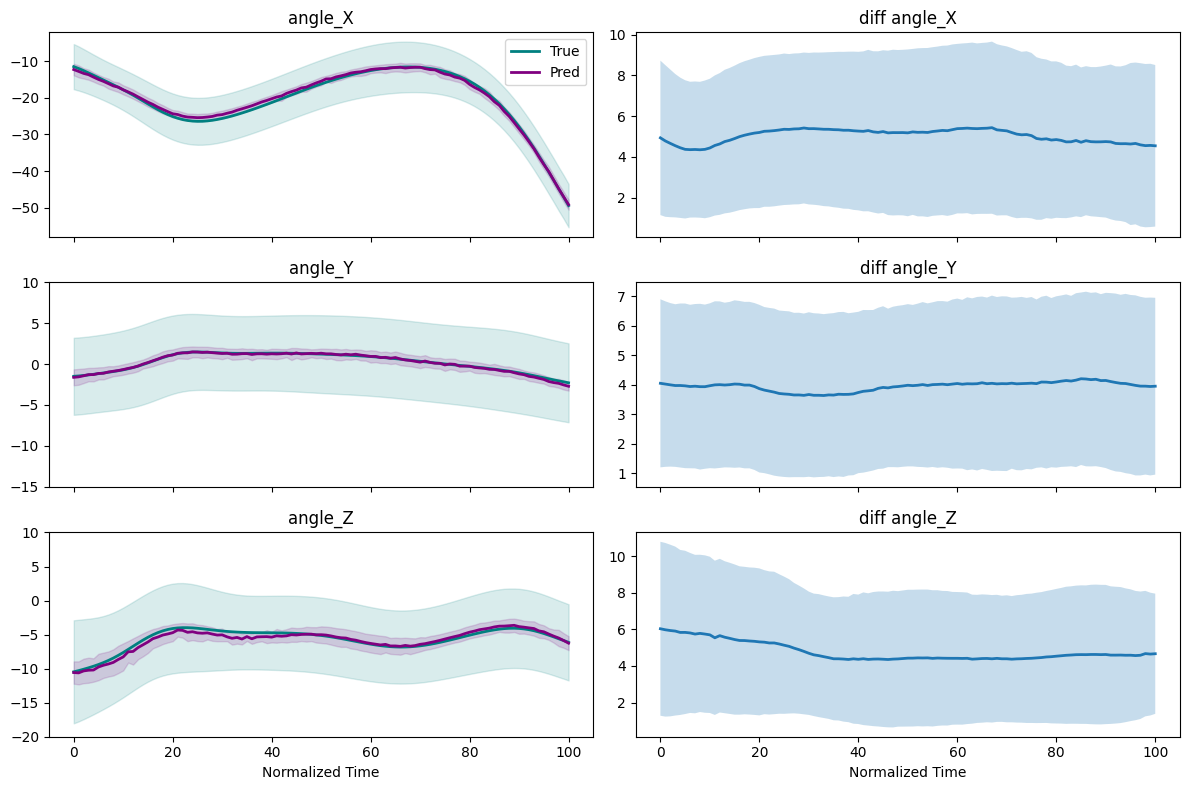

In [10]:
# === 3-row × 2-col summary:  True vs Pred  |  abs-diff ===
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np, matplotlib.pyplot as plt
pp  = PdfPages(join(targetDir, f"WHOLE_Total_result_{dataType}.pdf"))
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
time = np.linspace(0, 100, 101)
angle_labels = ['X', 'Y', 'Z']
for i, (T, P) in enumerate(zip([true_X, true_Y, true_Z],
                              [pred_X, pred_Y, pred_Z])):
   # --- if the matrices are still concatenated (n, 303) take the right slice
   if T.shape[1] == 303:
       sl = slice(i * 101, (i + 1) * 101)
       T, P = T[:, sl], P[:, sl]
   mT, sT = T.mean(0), T.std(0)
   mP, sP = P.mean(0), P.std(0)
   # -------- left column: True vs Pred --------
   ax = axes[i, 0]
   ax.plot(time, mT, lw=2, color='teal',   label='True')
   ax.plot(time, mP, lw=2, color='purple', label='Pred')
   ax.fill_between(time, mT - sT, mT + sT, alpha=0.15, color='teal')
   ax.fill_between(time, mP - sP, mP + sP, alpha=0.15, color='purple')
   ax.set_title(f'angle_{angle_labels[i]}')
   if i == 0:
       ax.legend()
   
   # Set custom y-axis limits for Y and Z to zoom out
   if i == 1:  # Y axis
       ax.set_ylim(-15, 10)
   elif i == 2:  # Z axis
       ax.set_ylim(-20, 10)
   
   # -------- right column: |True – Pred| --------
   diff      = np.abs(T - P)
   mD, sD    = diff.mean(0), diff.std(0)
   axd       = axes[i, 1]
   axd.plot(time, mD, lw=2)
   axd.fill_between(time, mD - sD, mD + sD, alpha=0.25)
   axd.set_title(f'diff angle_{angle_labels[i]}')

axes[-1, 0].set_xlabel('Normalized Time')
axes[-1, 1].set_xlabel('Normalized Time')
plt.tight_layout()
pp.savefig(fig)
pp.close()
plt.show()


In [12]:
"""
Test set evaluation using training-derived normalization ranges.
Computes per-trial and global metrics with proper trial filtering and variance (SD) calibration.
"""

import numpy as np
import pandas as pd
from dataclasses import dataclass, asdict

# ----------------------------- Configuration -------------------------------- #

AXES = ('X', 'Y', 'Z')
RANGE_EPS = 1e-8    # guard against zero range
PRINT_PER_AXIS = True

train_path = (r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning"
              r"\IMUforKnee\estimation\notsensor\DenseModel\MultiScaleCNN_optuna"
              r"\IWALQQ_1st_correction\angle\TruePredDiff_train.xlsx")

test_path = (r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\IMUforKnee\estimation\notsensor\DenseModel\Dense_1st_torch_optimized\IWALQQ_1st_correction\angle\TruePredDiff.xlsx")

# ----------------------------- Data Classes ---------------------------------- #

@dataclass
class AxisMetrics:
    axis: str
    training_range_deg: float
    training_min_deg: float
    training_max_deg: float
    global_rmse_deg: float
    global_nrmse_pct: float
    global_corr: float
    sd_ratio: float
    per_trial_corr_mean: float
    per_trial_corr_std: float
    per_trial_rmse_median_deg: float
    per_trial_rmse_iqr_deg: float
    per_trial_nrmse_mean_pct: float
    per_trial_nrmse_std_pct: float
    n_trials_total: int
    n_trials_used: int
    n_trials_dropped: int
    # Stored arrays (might be large; keep if you need downstream analyses)
    per_trial_corrs: np.ndarray
    per_trial_rmse_deg: np.ndarray
    per_trial_nrmse_pct: np.ndarray

# ----------------------------- Utility Functions ----------------------------- #

def load_axis_sheets(path, axis):
    """Load true & pred sheets for one axis (rows=time, cols=trials)."""
    t = pd.read_excel(path, sheet_name=f"true_{axis}", index_col=0)
    p = pd.read_excel(path, sheet_name=f"pred_{axis}", index_col=0)
    # Align columns defensively (should match already)
    common = [c for c in t.columns if c in p.columns]
    return t[common], p[common]

def compute_training_ranges(train_path, axes=AXES):
    """Compute global min/max & range per axis from training set true data."""
    ranges = {}
    print("Training data ranges (normalization denominators):")
    print("-"*70)
    for ax in axes:
        t, _ = load_axis_sheets(train_path, ax)
        vals = t.values
        gmin = np.nanmin(vals)
        gmax = np.nanmax(vals)
        rng = max(gmax - gmin, RANGE_EPS)
        ranges[ax] = dict(range=rng, min=gmin, max=gmax)
        print(f"{ax}: range={rng:.2f}° (min {gmin:.2f}°, max {gmax:.2f}°)")
    print("-"*70 + "\n")
    return ranges

def evaluate_axis(train_info, test_path, axis):
    """
    Evaluate model predictions for one axis on the *test* set using training range.
    Returns AxisMetrics.
    """
    training_range = train_info['range']
    t_min = train_info['min']
    t_max = train_info['max']

    true_df, pred_df = load_axis_sheets(test_path, axis)
    T = true_df.values
    P = pred_df.values

    # Identify & drop any trial with a NaN in true or pred
    invalid = np.isnan(T).any(axis=0) | np.isnan(P).any(axis=0)
    valid_mask = ~invalid
    T_valid = T[:, valid_mask]
    P_valid = P[:, valid_mask]

    n_total = T.shape[1]
    n_dropped = int(invalid.sum())
    n_used = int(valid_mask.sum())

    # Per-trial metrics
    per_trial_corrs = []
    per_trial_rmse = []
    for j in range(n_used):
        t_true = T_valid[:, j]
        t_pred = P_valid[:, j]
        # Correlation (guard zero variance)
        if np.std(t_true) > 0 and np.std(t_pred) > 0:
            c = np.corrcoef(t_true, t_pred)[0, 1]
        else:
            c = np.nan
        per_trial_corrs.append(c)
        per_trial_rmse.append(np.sqrt(np.mean((t_pred - t_true)**2)))

    per_trial_corrs = np.array(per_trial_corrs, dtype=float)
    per_trial_rmse = np.array(per_trial_rmse, dtype=float)

    # Remove NaN correlations for summary (e.g. flat signals)
    corr_clean = per_trial_corrs[~np.isnan(per_trial_corrs)]

    per_trial_nrmse_pct = 100.0 * per_trial_rmse / training_range

    # Global metrics using only valid trials
    flat_true = T_valid.reshape(-1)
    flat_pred = P_valid.reshape(-1)
    mask = ~np.isnan(flat_true) & ~np.isnan(flat_pred)
    flat_true = flat_true[mask]
    flat_pred = flat_pred[mask]

    global_rmse = np.sqrt(np.mean((flat_pred - flat_true)**2))
    if flat_true.size > 1 and np.std(flat_true) > 0 and np.std(flat_pred) > 0:
        global_corr = np.corrcoef(flat_true, flat_pred)[0, 1]
    else:
        global_corr = np.nan
    global_nrmse_pct = 100.0 * global_rmse / training_range

    # SD ratio (across-trial dispersion)
    true_sd_time = np.nanstd(T_valid, axis=1)
    pred_sd_time = np.nanstd(P_valid, axis=1)
    nz = true_sd_time > 0
    if nz.any():
        sd_ratio = np.mean(pred_sd_time[nz] / true_sd_time[nz])
    else:
        sd_ratio = np.nan

    # Robust summaries
    rmse_median = float(np.median(per_trial_rmse)) if per_trial_rmse.size else np.nan
    rmse_iqr = float(np.percentile(per_trial_rmse, 75) - np.percentile(per_trial_rmse, 25)) if per_trial_rmse.size else np.nan

    return AxisMetrics(
        axis=axis,
        training_range_deg=training_range,
        training_min_deg=t_min,
        training_max_deg=t_max,
        global_rmse_deg=global_rmse,
        global_nrmse_pct=global_nrmse_pct,
        global_corr=global_corr,
        sd_ratio=sd_ratio,
        per_trial_corr_mean=float(np.nanmean(corr_clean)) if corr_clean.size else np.nan,
        per_trial_corr_std=float(np.nanstd(corr_clean)) if corr_clean.size else np.nan,
        per_trial_rmse_median_deg=rmse_median,
        per_trial_rmse_iqr_deg=rmse_iqr,
        per_trial_nrmse_mean_pct=float(per_trial_nrmse_pct.mean()) if per_trial_nrmse_pct.size else np.nan,
        per_trial_nrmse_std_pct=float(per_trial_nrmse_pct.std()) if per_trial_nrmse_pct.size else np.nan,
        n_trials_total=n_total,
        n_trials_used=n_used,
        n_trials_dropped=n_dropped,
        per_trial_corrs=per_trial_corrs,
        per_trial_rmse_deg=per_trial_rmse,
        per_trial_nrmse_pct=per_trial_nrmse_pct
    )

def print_axis_table(metrics_list):
    """Pretty print per-axis summary."""
    print("="*95)
    print("TEST SET EVALUATION (normalized by training ranges)")
    print("="*95)
    header = ("Axis  "
              "Per-trial Corr (μ±σ)  "
              "GlobalCorr  "
              "GlobRMSE°  Glob nRMSE%  "
              "SD_ratio  "
              "Per-trial nRMSE μ±σ (%)  "
              "TrialsUsed/Total")
    print(header)
    print("-"*95)
    for m in metrics_list:
        print(f"{m.axis:<4} "
              f"{m.per_trial_corr_mean:>6.3f}±{m.per_trial_corr_std:>5.3f}  "
              f"{m.global_corr:>9.3f}  "
              f"{m.global_rmse_deg:>7.3f}   {m.global_nrmse_pct:>7.2f}   "
              f"{m.sd_ratio:>7.3f}  "
              f"{m.per_trial_nrmse_mean_pct:>6.2f}±{m.per_trial_nrmse_std_pct:>5.2f}   "
              f"{m.n_trials_used:>3}/{m.n_trials_total}")
    print("-"*95)
    # Macro averages (ignore NaNs)
    gm = [m.global_rmse_deg for m in metrics_list]
    gn = [m.global_nrmse_pct for m in metrics_list]
    gc = [m.global_corr for m in metrics_list]
    sr = [m.sd_ratio for m in metrics_list]
    macro_rmse = np.nanmean(gm)
    macro_nrmse = np.nanmean(gn)
    macro_corr = np.nanmean(gc)
    macro_sd_ratio = np.nanmean(sr)
    print(f"AVG   global_corr={macro_corr:.3f}  global_rmse={macro_rmse:.3f}°  "
          f"global_nRMSE={macro_nrmse:.2f}%  SD_ratio={macro_sd_ratio:.3f}")
    print("="*95)
    print("Notes:")
    print("  • SD_ratio <1 indicates under-dispersion (shrinkage); >1 over-dispersion; ≈1 well-calibrated variance.")
    print("  • global_nRMSE uses a *single* training min-max per axis; per-trial nRMSE is mean of each trial's RMSE / training range.")
    print("  • Use stored per_trial_rmse_deg arrays for ΔRMSE vs naive baseline.")
    print()

def main():
    # 1. Compute training ranges
    training_ranges = compute_training_ranges(train_path, AXES)

    # 2. Evaluate each axis on test
    metrics = []
    for ax in AXES:
        m = evaluate_axis(training_ranges[ax], test_path, ax)
        metrics.append(m)

    # 3. Print table
    print_axis_table(metrics)

    # 4. Optional: convert to DataFrame for saving
    records = []
    for m in metrics:
        rec = asdict(m).copy()
        # Remove large arrays if you want a compact CSV
        rec.pop('per_trial_corrs')
        rec.pop('per_trial_rmse_deg')
        rec.pop('per_trial_nrmse_pct')
        records.append(rec)
    df_summary = pd.DataFrame(records)
    # Example (uncomment to save):
    # df_summary.to_csv("test_metrics_summary.csv", index=False)

    return metrics, df_summary, training_ranges

if __name__ == "__main__":
    metrics, df_summary, training_ranges = main()


Training data ranges (normalization denominators):
----------------------------------------------------------------------
X: range=75.98° (min -67.41°, max 8.56°)
Y: range=27.80° (min -13.18°, max 14.61°)
Z: range=55.54° (min -41.26°, max 14.28°)
----------------------------------------------------------------------

TEST SET EVALUATION (normalized by training ranges)
Axis  Per-trial Corr (μ±σ)  GlobalCorr  GlobRMSE°  Glob nRMSE%  SD_ratio  Per-trial nRMSE μ±σ (%)  TrialsUsed/Total
-----------------------------------------------------------------------------------------------
X     0.920±0.064      0.631    9.916     13.05     1.174   10.62± 7.58   875/875
Y     0.515±0.263      0.478    4.497     16.18     0.702   14.11± 7.93   875/875
Z     0.440±0.279      0.152    8.345     15.02     0.966   12.85± 7.79   875/875
-----------------------------------------------------------------------------------------------
AVG   global_corr=0.420  global_rmse=7.586°  global_nRMSE=14.75%  SD_ratio=

In [35]:
# ---- Time‑averaged SD ratio for each axis ---------------------------
# assumes you already have true_X, true_Y, true_Z and pred_X, pred_Y, pred_Z
import numpy as np

angle_labels = ['X', 'Y', 'Z']
ratios = {}

for i, (T, P) in enumerate(zip([true_X, true_Y, true_Z],
                               [pred_X, pred_Y, pred_Z])):
    # if the matrices are stored concatenated (n, 303) split them
    if T.shape[1] == 303:                       # 3 × 101 columns
        sl = slice(i * 101, (i + 1) * 101)
        T, P = T[:, sl], P[:, sl]

    sT = T.std(axis=0)          # SD of true trials at each time point
    sP = P.std(axis=0)          # SD of predicted trials
    ratio = (sP / sT).mean()    # average over the 101 time samples

    ratios[angle_labels[i]] = ratio

# print a quick summary
for k, r in ratios.items():
    print(f"Axis {k}: mean SD ratio = {r:.3f}")


Axis X: mean SD ratio = 0.183
Axis Y: mean SD ratio = 0.136
Axis Z: mean SD ratio = 0.197


In [46]:
# Enhanced SD ratio analysis for individual variance assessment
import numpy as np
import matplotlib.pyplot as plt

def comprehensive_sd_ratio_analysis(true_X, true_Y, true_Z, pred_X, pred_Y, pred_Z):
    """
    Comprehensive analysis of how well the model captures individual variability
    """
    angle_labels = ['X', 'Y', 'Z']
    true_data = [true_X, true_Y, true_Z]
    pred_data = [pred_X, pred_Y, pred_Z]
    
    results = {}
    
    print("="*70)
    print("INDIVIDUAL VARIABILITY ANALYSIS (SD Ratio Method)")
    print("="*70)
    
    for i, axis in enumerate(angle_labels):
        T, P = true_data[i], pred_data[i]
        
        # Handle concatenated format if needed
        if T.shape[1] == 303:
            sl = slice(i * 101, (i + 1) * 101)
            T, P = T[:, sl], P[:, sl]
        
        # Calculate SD at each time point
        sT = T.std(axis=0)  # True variability across trials
        sP = P.std(axis=0)  # Predicted variability across trials
        
        # Overall metrics
        mean_ratio = (sP / sT).mean()
        median_ratio = np.median(sP / sT)
        
        # Temporal analysis
        ratios_over_time = sP / sT
        min_ratio = np.min(ratios_over_time)
        max_ratio = np.max(ratios_over_time)
        
        # Identify time periods with good/poor individual prediction
        good_timepoints = np.sum((ratios_over_time >= 0.8) & (ratios_over_time <= 1.2))
        poor_timepoints = np.sum((ratios_over_time < 0.5) | (ratios_over_time > 2.0))
        
        # Store results
        results[axis] = {
            'mean_ratio': mean_ratio,
            'median_ratio': median_ratio,
            'min_ratio': min_ratio,
            'max_ratio': max_ratio,
            'good_timepoints': good_timepoints,
            'poor_timepoints': poor_timepoints,
            'ratios_over_time': ratios_over_time,
            'true_sd': sT,
            'pred_sd': sP
        }
        
        # Interpretation
        if 0.8 <= mean_ratio <= 1.2:
            interpretation = " EXCELLENT individual variance capture"
        elif 0.6 <= mean_ratio <= 1.4:
            interpretation = "✓ GOOD individual variance capture"
        elif 0.4 <= mean_ratio <= 1.6:
            interpretation = " MODERATE individual variance capture"
        else:
            interpretation = " POOR individual variance capture"
        
        print(f"\nAxis {axis}:")
        print(f"  Mean SD Ratio: {mean_ratio:.3f} - {interpretation}")
        print(f"  Range: {min_ratio:.3f} to {max_ratio:.3f}")
        print(f"  Good timepoints (0.8-1.2): {good_timepoints}/101 ({100*good_timepoints/101:.1f}%)")
        print(f"  Poor timepoints (<0.5 or >2.0): {poor_timepoints}/101 ({100*poor_timepoints/101:.1f}%)")
    
    # Overall assessment
    print(f"\n" + "="*70)
    print("OVERALL INDIVIDUAL PREDICTION CAPABILITY:")
    print("="*70)
    
    all_ratios = [results[axis]['mean_ratio'] for axis in angle_labels]
    overall_mean = np.mean(all_ratios)
    
    print(f"Overall Mean SD Ratio: {overall_mean:.3f}")
    
    if overall_mean < 0.7:
        print(" MODEL TENDS TO UNDER-PREDICT individual differences")
        print("   → All predictions are too similar to the population average")
        print("   → Poor personalization capability")
    elif overall_mean > 1.3:
        print(" MODEL TENDS TO OVER-PREDICT individual differences") 
        print("   → Predictions are more variable than reality")
        print("   → May be adding noise/artifacts")
    else:
        print(" MODEL CAPTURES individual differences reasonably well")
        print("   → Good balance between personalization and stability")
    
    # Phase-specific analysis
    print(f"\n" + "="*70)
    print("MOVEMENT PHASE ANALYSIS:")
    print("="*70)
    
    for axis in angle_labels:
        ratios = results[axis]['ratios_over_time']
        
        # Identify problematic phases
        early_phase = ratios[:25].mean()   # 0-25% of gait cycle
        mid_phase = ratios[25:75].mean()   # 25-75% of gait cycle  
        late_phase = ratios[75:].mean()    # 75-100% of gait cycle
        
        print(f"\nAxis {axis} - Gait Phase Performance:")
        print(f"  Early phase (0-25%):   {early_phase:.3f}")
        print(f"  Mid phase (25-75%):    {mid_phase:.3f}")
        print(f"  Late phase (75-100%):  {late_phase:.3f}")
        
        # Identify worst performing phase
        phases = [('Early', early_phase), ('Mid', mid_phase), ('Late', late_phase)]
        worst_phase = min(phases, key=lambda x: abs(x[1] - 1.0))
        best_phase = max(phases, key=lambda x: 1 / abs(x[1] - 1.0))
        
        print(f"  Best phase: {best_phase[0]} ({best_phase[1]:.3f})")
        print(f"  Worst phase: {worst_phase[0]} ({worst_phase[1]:.3f})")
    
    return results

# Additional utility function to compare with your correlation results
def compare_metrics(sd_results, correlation_results):
    """
    Compare SD ratio results with correlation-based results
    """
    print(f"\n" + "="*70)
    print("METRIC COMPARISON: SD Ratio vs Correlation")
    print("="*70)
    print(f"{'Axis':<6} {'SD Ratio':<10} {'Correlation':<12} {'Interpretation':<25}")
    print("-"*70)
    
    for axis in ['X', 'Y', 'Z']:
        sd_ratio = sd_results[axis]['mean_ratio']
        correlation = correlation_results.get(f'{axis}_correlation_mean', 'N/A')
        
        # Interpretation logic
        if sd_ratio > 0.8 and sd_ratio < 1.2 and correlation > 0.8:
            interp = "Excellent overall"
        elif sd_ratio < 0.7 and correlation > 0.8:
            interp = "Good pattern, poor individuality"
        elif sd_ratio > 0.8 and correlation < 0.7:
            interp = "Good individuality, poor pattern"
        else:
            interp = "Needs improvement"
        
        print(f"{axis:<6} {sd_ratio:<10.3f} {correlation:<12.3f} {interp:<25}")
    
    print(f"\nKey Insight:")
    print(f"• High correlation + Low SD ratio = Model predicts average pattern well but lacks personalization")
    print(f"• High correlation + Good SD ratio = Model captures both pattern and individual differences")


results = comprehensive_sd_ratio_analysis(true_X, true_Y, true_Z, pred_X, pred_Y, pred_Z)

INDIVIDUAL VARIABILITY ANALYSIS (SD Ratio Method)

Axis X:
  Mean SD Ratio: 0.183 -  POOR individual variance capture
  Range: 0.126 to 0.271
  Good timepoints (0.8-1.2): 0/101 (0.0%)
  Poor timepoints (<0.5 or >2.0): 101/101 (100.0%)

Axis Y:
  Mean SD Ratio: 0.136 -  POOR individual variance capture
  Range: 0.101 to 0.206
  Good timepoints (0.8-1.2): 0/101 (0.0%)
  Poor timepoints (<0.5 or >2.0): 101/101 (100.0%)

Axis Z:
  Mean SD Ratio: 0.197 -  POOR individual variance capture
  Range: 0.112 to 0.303
  Good timepoints (0.8-1.2): 0/101 (0.0%)
  Poor timepoints (<0.5 or >2.0): 101/101 (100.0%)

OVERALL INDIVIDUAL PREDICTION CAPABILITY:
Overall Mean SD Ratio: 0.172
 MODEL TENDS TO UNDER-PREDICT individual differences
   → All predictions are too similar to the population average
   → Poor personalization capability

MOVEMENT PHASE ANALYSIS:

Axis X - Gait Phase Performance:
  Early phase (0-25%):   0.207
  Mid phase (25-75%):    0.160
  Late phase (75-100%):  0.205
  Best phase: Ear

# Same Analysis on Training Data


In [37]:
# Angle prediction model (train data) - FIXED VERSION
for numFold in range(0, 5):
    # Load model - FIXED: Use correct file naming pattern and loading method
    dir_savedTrainedModel = join(MODEL_DIR, f"{dataType}_fold_{numFold}_optuna_best.pt")
    print(f"Loading model: {dir_savedTrainedModel}")
    
    # Try different loading methods depending on how the model was saved
    try:
        # First try torch.jit.load for TorchScript models
        my_model = torch.jit.load(dir_savedTrainedModel, map_location='cpu')
        print("Loaded as TorchScript model")
    except RuntimeError as e:
        if "constants.pkl" in str(e):
            # If it fails with constants.pkl error, try regular torch.load
            print("TorchScript failed, trying regular torch.load...")
            my_model = torch.load(dir_savedTrainedModel, map_location='cpu', weights_only=False)
            print("Loaded as regular PyTorch model")
        else:
            raise e
    
    my_model.eval()
    
    with torch.no_grad():
        # Load data
        load_train = np.load(join(DATA_DIR, f"{numFold}_fold_final_train.npz"))
        load_scaler4Y = load(
            open(join(DATA_DIR, f"{numFold}_fold_scaler4Y_{dataType}.pkl"), "rb")
        )
        
        print(f"Processing fold {numFold} with {load_train['final_X_train'].shape[0]} training samples")
        
        # Iterate through individual data for each fold
        for dataIndex in range(load_train["final_X_train"].shape[0]):
            # Prepare input and ground truth data
            X_train = np.squeeze(load_train["final_X_train"][dataIndex])
            X_train = X_train[None, :]  # Add batch dimension
            Y_true = load_train[f"final_Y_{dataType}_train"][dataIndex]
            
            # Inference
            Y_pred = my_model(
                torch.from_numpy(X_train).type(torch.FloatTensor))
            Y_pred = Y_pred.cpu().detach().numpy()
            Y_pred = np.reshape(Y_pred, [3, -1])
            Y_pred = np.transpose(Y_pred)
            
            # Reshape Y_true the same way as Y_pred (convert 303-length flat array to 101x3 matrix)
            Y_true = np.reshape(Y_true, [3, -1])
            Y_true = np.transpose(Y_true)
            
            # Rescale data back to original size
            Y_true_pick_afterscaler = (Y_true - load_scaler4Y.min_) / load_scaler4Y.scale_
            Y_pred_pick_afterscaler = (Y_pred - load_scaler4Y.min_) / load_scaler4Y.scale_
            
            df_true = pd.DataFrame(Y_true_pick_afterscaler, columns=['X_True', 'Y_True', 'Z_True'])
            df_pred = pd.DataFrame(Y_pred_pick_afterscaler, columns=['X_Pred', 'Y_Pred', 'Z_Pred'])
            df_save = pd.concat([df_true, df_pred], axis=1)
            dfSaveDir = join(motherDir, modelVersion, nameDataset, dataType, f"{numFold}_fold_train")
            ensure_dir(dfSaveDir)
            df_save.to_excel(join(dfSaveDir, f"{dataIndex}.xlsx"))
        #     break  # For train data loop break
        
        print(f"Fold {numFold} training data completed successfully!")
    # break  # For fold loop break

print("All training data folds completed successfully!")

Loading model: R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\Optuna_AutoSearch\models\final_models\angle_fold_0_optuna_best.pt
TorchScript failed, trying regular torch.load...
Loaded as regular PyTorch model
Processing fold 0 with 722 training samples
Fold 0 training data completed successfully!
Loading model: R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\Optuna_AutoSearch\models\final_models\angle_fold_1_optuna_best.pt
TorchScript failed, trying regular torch.load...
Loaded as regular PyTorch model
Processing fold 1 with 667 training samples
Fold 1 training data completed successfully!
Loading model: R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\Optuna_AutoSearch\models\final_models\angle_fold_2_optuna_best.pt
TorchScript failed, trying regular torch.load...
Loaded as regular PyTorch model
Processing fold 2 with 722 training samples
Fold 2 training data completed 

In [38]:
# Rebuild arrays from training Excel files
targetDir_train = join(motherDir,modelVersion,nameDataset,dataType)

true_train_X = np.array([])
pred_train_X = np.array([])
true_train_Y = np.array([])
pred_train_Y = np.array([])
true_train_Z = np.array([])
pred_train_Z = np.array([])

for fold in ["0_fold_train","1_fold_train","2_fold_train","3_fold_train","4_fold_train"]:
    list_results = natsorted([_ for _ in os.listdir(join(targetDir_train,fold)) if _.endswith(".xlsx")])
    for result in list_results:
        df = pd.read_excel(join(targetDir_train,fold,result))
        
        for axe in ["X","Y","Z"]:
            true_train_data = np.expand_dims(df[f"{axe}_True"].to_numpy(), axis=0)
            pred_train_data = np.expand_dims(df[f"{axe}_Pred"].to_numpy(), axis=0)
            
            if len(globals()[f"true_train_{axe}"]) == 0:
                globals()[f"true_train_{axe}"] = true_train_data
                globals()[f"pred_train_{axe}"] = pred_train_data
            else:
                globals()[f"true_train_{axe}"] = np.concatenate((globals()[f"true_train_{axe}"], true_train_data), 0)
                globals()[f"pred_train_{axe}"] = np.concatenate((globals()[f"pred_train_{axe}"], pred_train_data), 0)

print("Arrays rebuilt. Now run your Excel writer code.")

Arrays rebuilt. Now run your Excel writer code.


In [39]:
# Save training arrays to Excel - FIXED VERSION
try:
    import xlsxwriter
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xlsxwriter"])
    import xlsxwriter

totalDir = join(motherDir, modelVersion, nameDataset, dataType)
writer = pd.ExcelWriter(join(totalDir, 'TruePredDiff_train.xlsx'), engine='xlsxwriter')

for axe in ["X", "Y", "Z"]:
    for sess in ["true", "pred"]:
        # FIXED: Use the correct variable names with "_train"
        dataName = f"{sess}_train_{axe}"
        df = makeDataframe(globals()[dataName])
        # Save with simplified sheet names (without "_train")
        sheet_name = f"{sess}_{axe}"
        df.to_excel(writer, sheet_name=sheet_name, index=False)
    
    # Calculate differences using the correct variable names
    df_diff = makeDataframe(abs(globals()[f"true_train_{axe}"] - globals()[f"pred_train_{axe}"]))
    df_diff.to_excel(writer, sheet_name=f"diff_{axe}", index=False)

writer.close()

print("Training data saved successfully!")
print("Sheets created:")
for axe in ["X", "Y", "Z"]:
    print(f"  - true_{axe}, pred_{axe}, diff_{axe}")

Training data saved successfully!
Sheets created:
  - true_X, pred_X, diff_X
  - true_Y, pred_Y, diff_Y
  - true_Z, pred_Z, diff_Z


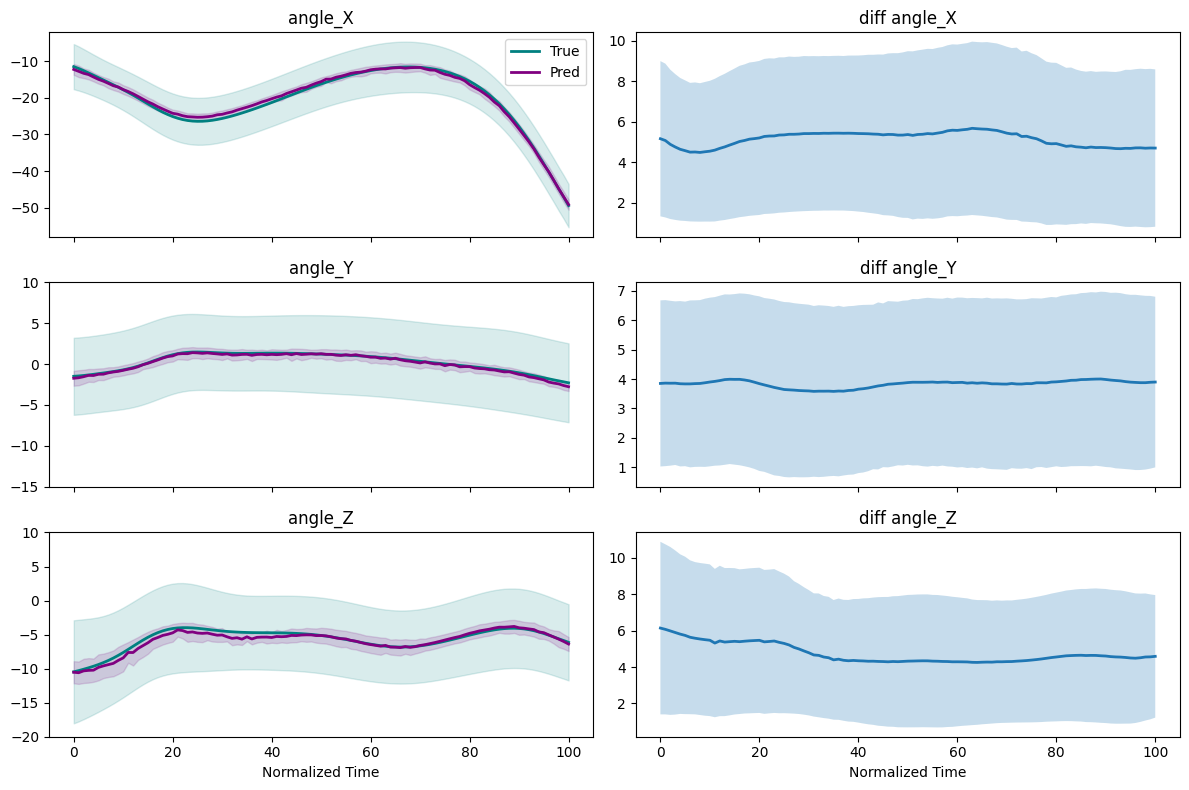

In [40]:
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np, matplotlib.pyplot as plt
pp  = PdfPages(join(targetDir, f"WHOLE_Total_result_train_{dataType}.pdf"))
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
time = np.linspace(0, 100, 101)
angle_labels = ['X', 'Y', 'Z']
for i, (T, P) in enumerate(zip([true_train_X, true_train_Y, true_train_Z],
                              [pred_train_X, pred_train_Y, pred_train_Z])):
   # --- if the matrices are still concatenated (n, 303) take the right slice
   if T.shape[1] == 303:
       sl = slice(i * 101, (i + 1) * 101)
       T, P = T[:, sl], P[:, sl]
   mT, sT = T.mean(0), T.std(0)
   mP, sP = P.mean(0), P.std(0)
   # -------- left column: True vs Pred --------
   ax = axes[i, 0]
   ax.plot(time, mT, lw=2, color='teal',   label='True')
   ax.plot(time, mP, lw=2, color='purple', label='Pred')
   ax.fill_between(time, mT - sT, mT + sT, alpha=0.15, color='teal')
   ax.fill_between(time, mP - sP, mP + sP, alpha=0.15, color='purple')
   ax.set_title(f'angle_{angle_labels[i]}')
   if i == 0:
       ax.legend()
   
   # Set custom y-axis limits for Y and Z to zoom out
   if i == 1:  # Y axis
       ax.set_ylim(-15, 10)
   elif i == 2:  # Z axis
       ax.set_ylim(-20, 10)
   
   # -------- right column: |True – Pred| --------
   diff      = np.abs(T - P)
   mD, sD    = diff.mean(0), diff.std(0)
   axd       = axes[i, 1]
   axd.plot(time, mD, lw=2)
   axd.fill_between(time, mD - sD, mD + sD, alpha=0.25)
   axd.set_title(f'diff angle_{angle_labels[i]}')

axes[-1, 0].set_xlabel('Normalized Time')
axes[-1, 1].set_xlabel('Normalized Time')
plt.tight_layout()
pp.savefig(fig)
pp.close()
plt.show()


In [42]:
# Calculate correlation coefficient and relative RMSE for each axis (FIXED - using overall population range)
import numpy as np
import pandas as pd

train_results = {}
axis_names = ['X', 'Y', 'Z']

# Use the specific file path
excel_file_path = r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\IMUforKnee\estimation\notsensor\DenseModel\Optuna_AutoSearch\IWALQQ_1st_correction\angle\TruePredDiff_Train.xlsx"

# First pass: Calculate overall population ranges for each axis
overall_ranges = {}
for axis in axis_names:
    true_data = pd.read_excel(excel_file_path, sheet_name=f'true_{axis}', index_col=0)
    
    # Calculate overall population range (min/max across ALL trials)
    overall_min = np.nanmin(true_data.values)
    overall_max = np.nanmax(true_data.values)
    overall_ranges[axis] = overall_max - overall_min
    
    print(f"Axis {axis} - Overall population range: {overall_ranges[axis]:.2f}° (from {overall_min:.2f}° to {overall_max:.2f}°)")

print("\n" + "="*70)

# Second pass: Calculate metrics using overall population ranges
for axis in axis_names:
    # Read the true and predicted data sheets
    true_data = pd.read_excel(excel_file_path, sheet_name=f'true_{axis}', index_col=0)
    pred_data = pd.read_excel(excel_file_path, sheet_name=f'pred_{axis}', index_col=0)
    
    # Calculate correlation for each trial (each column)
    correlations = []
    rel_rmses = []
    
    for trial_col in true_data.columns:  # For each trial (column)
        true_trial = true_data[trial_col].values    # 101 time points for this trial
        pred_trial = pred_data[trial_col].values    # 101 time points for this trial
        
        # Skip if there are NaN values
        if np.isnan(true_trial).any() or np.isnan(pred_trial).any():
            continue
            
        # Correlation for this trial
        trial_corr = np.corrcoef(true_trial, pred_trial)[0, 1]
        correlations.append(trial_corr)
        
        # FIXED: Relative RMSE using overall population range (not individual trial range)
        rmse = np.sqrt(np.mean((pred_trial - true_trial) ** 2))
        rel_rmse = 100 * rmse / overall_ranges[axis]  # Use overall range, not individual trial range
        rel_rmses.append(rel_rmse)
    
    # Average across all trials
    train_results[f'{axis}_correlation_mean'] = np.mean(correlations)
    train_results[f'{axis}_correlation_std'] = np.std(correlations)
    train_results[f'{axis}_rel_rmse_mean'] = np.mean(rel_rmses)
    train_results[f'{axis}_rel_rmse_std'] = np.std(rel_rmses)

# Print train_results
print("Train Results Summary (FIXED - Overall Population Range-based Relative RMSE):")
print("-" * 70)
print(f"{'Axis':<4} {'Corr Mean':<10} {'Corr Std':<10} {'RMSE Mean (%)':<12} {'RMSE Std (%)':<12}")
print("-" * 70)
for axis in axis_names:
    corr_mean = train_results[f'{axis}_correlation_mean']
    corr_std = train_results[f'{axis}_correlation_std']
    rmse_mean = train_results[f'{axis}_rel_rmse_mean']
    rmse_std = train_results[f'{axis}_rel_rmse_std']
    print(f"{axis:<4} {corr_mean:<10.3f} {corr_std:<10.3f} {rmse_mean:<12.2f} {rmse_std:<12.2f}")

print("\n" + "="*70)
print("Key differences from original:")
print("- Using overall population range for normalization")
print("- Should now match your visual assessment better")
print("- More stable and interpretable relative RMSE values")

Axis X - Overall population range: 75.98° (from -67.41° to 8.56°)
Axis Y - Overall population range: 27.80° (from -13.18° to 14.61°)
Axis Z - Overall population range: 55.54° (from -41.26° to 14.28°)

Train Results Summary (FIXED - Overall Population Range-based Relative RMSE):
----------------------------------------------------------------------
Axis Corr Mean  Corr Std   RMSE Mean (%) RMSE Std (%)
----------------------------------------------------------------------
X    0.936      0.067      7.53         3.96        
Y    0.620      0.304      14.61        9.26        
Z    0.449      0.320      9.55         5.17        

Key differences from original:
- Using overall population range for normalization
- Should now match your visual assessment better
- More stable and interpretable relative RMSE values


In [44]:
import numpy as np
import pandas as pd

def compare_prediction_spread(excel_file_path):
    """
    Compare the spread (variability) of predictions vs true values
    This directly answers: "Is the spread of predictions similar to the spread of true values?"
    """
    
    axis_names = ['X', 'Y', 'Z']
    
    print("PREDICTION SPREAD ANALYSIS")
    print("=" * 60)
    print(f"{'Axis':<4} {'True Std':<10} {'Pred Std':<10} {'Ratio':<8} {'Status':<20}")
    print("-" * 60)
    
    for axis in axis_names:
        # Read data
        true_data = pd.read_excel(excel_file_path, sheet_name=f'true_{axis}', index_col=0)
        pred_data = pd.read_excel(excel_file_path, sheet_name=f'pred_{axis}', index_col=0)
        
        # Convert to numpy arrays
        T = true_data.values  # (trials, timepoints)
        P = pred_data.values  # (trials, timepoints)
        
        # Calculate standard deviation across trials for each timepoint
        # This is exactly what creates the shaded regions in your plots
        true_std_per_timepoint = T.std(axis=0)  # std across trials at each timepoint
        pred_std_per_timepoint = P.std(axis=0)  # std across trials at each timepoint
        
        # Average standard deviation across all timepoints
        avg_true_std = np.mean(true_std_per_timepoint)
        avg_pred_std = np.mean(pred_std_per_timepoint)
        
        # Ratio: how much smaller/larger is prediction spread vs true spread
        spread_ratio = avg_pred_std / avg_true_std
        
        # Determine status
        if spread_ratio < 0.8:
            status = "OVERCONFIDENT"
        elif spread_ratio > 1.2:
            status = "UNDERCONFIDENT" 
        else:
            status = "WELL CALIBRATED"
        
        print(f"{axis:<4} {avg_true_std:<10.2f} {avg_pred_std:<10.2f} {spread_ratio:<8.3f} {status:<20}")
    
    print("-" * 60)
    print("\nInterpretation:")
    print("- Ratio < 0.8: OVERCONFIDENT (predictions too consistent)")
    print("- Ratio > 1.2: UNDERCONFIDENT (predictions too variable)")
    print("- Ratio 0.8-1.2: WELL CALIBRATED (appropriate variability)")
    print("\nThis directly measures what you see in the plot:")
    print("- Purple shaded region width vs Teal shaded region width")

# Run the analysis
if __name__ == "__main__":
    excel_file_path = r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\IMUforKnee\estimation\notsensor\DenseModel\Optuna_AutoSearch\IWALQQ_1st_correction\angle\TruePredDiff_Train.xlsx"

    
    compare_prediction_spread(excel_file_path)

PREDICTION SPREAD ANALYSIS
Axis True Std   Pred Std   Ratio    Status              
------------------------------------------------------------
X    8.71       8.06       0.926    WELL CALIBRATED     
Y    1.65       1.17       0.707    OVERCONFIDENT       
Z    2.93       1.72       0.587    OVERCONFIDENT       
------------------------------------------------------------

Interpretation:
- Ratio < 0.8: OVERCONFIDENT (predictions too consistent)
- Ratio > 1.2: UNDERCONFIDENT (predictions too variable)
- Ratio 0.8-1.2: WELL CALIBRATED (appropriate variability)

This directly measures what you see in the plot:
- Purple shaded region width vs Teal shaded region width
